Title: cluster_plt_all_days.ipynb

Purpose: Make a plot representing the clustering with all days

Author: Onno Nennecke on 15.06.2025 Modified: 16.05.2026

Input data: 

- centroids and labels
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc.npz'
- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'
- PSL Data
    - This file lies here: /climca/people/onennecke/model_output/psl_anomaly/not_bc/

Output data:

- Cluster Plot: cluster_analysis_2x2, cluster_analysis_combined, cluster_analysis_combined_v2
    - This file lies here: /home/onennecke/Code/Figures/

In [1]:
# Load libraries
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from datetime import datetime, timedelta
from matplotlib.patches import Patch
import cftime
import joblib
from scipy.spatial.distance import cdist


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4, ll = True, bl = True, label_size = 14):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [3]:
def create_date_list(LEE_data, cluster_data):
    """
    For each row in LEE_data, take 'date_start' and 'date_end' strings (YYYY-MM-DD),
    compute all calendar dates in that interval (inclusive), wrapping across year-end
    if start > end, but explicitly skip any leap day (Feb 29).

    Parameters:
        LEE_data (pd.DataFrame): must contain 'date_start' and 'date_end' as YYYY-MM-DD.

    Returns:
        list[str]: flat list of dates (YYYY-MM-DD) covering each event, without Feb 29.
    """
    # date_list = []
    records = []
    for start_str, end_str, esm_run in zip(LEE_data['date_start'], LEE_data['date_end'], LEE_data['ESM_run']):
        start_date = datetime.strptime(start_str, "%Y-%m-%d").date()
        end_date   = datetime.strptime(end_str,   "%Y-%m-%d").date()
        num_days = (end_date - start_date).days + 1
        for offset in range(num_days):
            current = start_date + timedelta(days=offset)
            if current.month == 2 and current.day == 29:
                continue
            # current64 = np.datetime64(current)  # now datetime64[ns]
            current_cf = cftime.DatetimeNoLeap(
                current.year,
                current.month,
                current.day
            )
            try:
                cluster = cluster_data.sel(
                    time=current_cf,
                    ESM_run=esm_run#,
                    # method="nearest"
                ).item()

            except Exception as e:
                print(
                    f"[WARN] Missing cluster for {current_cf} "
                    f"(ESM_run={esm_run}) → inserting NaN"
                )
                cluster = np.nan
            # cluster = cluster_data.sel(time=current_cf, ESM_run=esm_run).item()
            # cluster = cluster_data.sel(time=current64, ESM_run=esm_run).item()
            records.append({"Dates": current.strftime("%Y-%m-%d"), "ESM_run": esm_run, "Cluster": cluster})
    return pd.DataFrame(records)



### Read LEE data

In [4]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

# Read the LEE data
LEE_dat_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_fut.csv')

LEE_7_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_fut.csv')

LEE_14_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_fut.csv')


In [5]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]

# Rename ESM_run for ERA5_hist_week to ERA5_hist
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_7['ESM_run'] = LEE_7['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_14['ESM_run'] = LEE_14['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})

# Remove all events that start or end outside of October-March
LEE_dat = LEE_dat[((LEE_dat['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_dat['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_7 = LEE_7[((LEE_7['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_7['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_14 = LEE_14[((LEE_14['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_14['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]


# Same for the future data

# Remove all events that start or end outside of October-March
LEE_dat_fut = LEE_dat_fut[((LEE_dat_fut['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_dat_fut['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_7_fut = LEE_7_fut[((LEE_7_fut['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_7_fut['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_14_fut = LEE_14_fut[((LEE_14_fut['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_14_fut['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]


### Read PSL data

In [6]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
ts_datasets['ESM_run'] = ts_datasets['ESM_run'].str.replace('CESM2_LE_LE2', 'CESM2_LE2', regex=False)

ts_datasets

ts_datasets_filtered = ts_datasets.copy()

date_map = (
    LEE_dat.groupby("ESM_run")["date_start"]
    .apply(list)
    .to_dict()
)
# ts_datasets_filtered = ts_datasets.copy()
# mask = xr.zeros_like(ts_datasets_filtered.time, dtype=bool)

# for esm, dates in date_map.items():
#     dates_formatted = [
#         cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
#         for date in dates
#     ]

#     mask = mask | (
#         (ts_datasets_filtered.ESM_run == esm) &
#         (ts_datasets_filtered.time.isin(dates_formatted))
#     )

# ts_datasets_filtered = ts_datasets_filtered.where(mask, drop=True)

# Same for the future data

path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc_fut/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets_fut = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
ts_datasets_fut['ESM_run'] = ts_datasets_fut['ESM_run'].str.replace('CESM2_LE_LE2', 'CESM2_LE2', regex=False)

ts_datasets_fut

ts_datasets_fut_filtered = ts_datasets_fut.copy()

date_map = (
    LEE_dat_fut.groupby("ESM_run")["date_start"]
    .apply(list)
    .to_dict()
)
# ts_datasets_fut_filtered = ts_datasets_fut.copy()
# mask = xr.zeros_like(ts_datasets_fut_filtered.time, dtype=bool)

# for esm, dates in date_map.items():
#     dates_formatted = [
#         cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
#         for date in dates
#     ]

#     mask = mask | (
#         (ts_datasets_fut_filtered.ESM_run == esm) &
#         (ts_datasets_fut_filtered.time.isin(dates_formatted))
#     )

# ts_datasets_fut_filtered = ts_datasets_fut_filtered.where(mask, drop=True)

### Read cluster data

In [7]:
# Read weights and PCA components for later use
# pca = joblib.load('/home/onennecke/psl_clustering/pca_model.pkl')
# centroids_pca = joblib.load('/home/onennecke/psl_clustering/kmeans_centers_pca.pkl')
# weights = np.load('/home/onennecke/psl_clustering/weights.npy')


In [8]:
# psl = ts_datasets['psl']

# # Stack lat/lon into a single "space" dimension to prepare for PCA and clustering
# psl_stacked = psl.stack(sample=("time", "ESM_run"))
# # remove samples that are fully NaN
# psl_stacked = psl_stacked.dropna(dim="sample", how="all")
# psl_2d = psl_stacked.stack(space=("lat", "lon"))
# X = psl_2d.values


# X_weighted = X * weights[np.newaxis, :]

# # PCA to reduce dimensionality
# X_pca = pca.transform(X_weighted)  # shape: (n_times, n_eofs)

# # Same for the future data
# psl_fut = ts_datasets_fut['psl']

# # Stack lat/lon into a single "space" dimension to prepare for PCA and clustering
# psl_stacked_fut = psl_fut.stack(sample=("time", "ESM_run"))
# # remove samples that are fully NaN
# psl_stacked_fut = psl_stacked_fut.dropna(dim="sample", how="all")
# psl_2d_fut = psl_stacked_fut.stack(space=("lat", "lon"))
# X_fut = psl_2d_fut.values


# X_weighted_fut = X_fut * weights[np.newaxis, :]

# # PCA to reduce dimensionality
# X_pca_fut = pca.transform(X_weighted_fut)  # shape: (n_times, n_eofs)



In [9]:
# distances = cdist(X_pca, centroids_pca)
# new_labels = np.argmin(distances, axis=1)

# distances_fut = cdist(X_pca_fut, centroids_pca)
# new_labels_fut = np.argmin(distances_fut, axis=1)

In [10]:

# cluster_da = xr.DataArray(
#     new_labels,
#     coords={"sample": psl_stacked.sample},
#     dims=["sample"]
# )

# cluster_da = cluster_da.unstack("sample")
# cluster_da
# cluster_da = cluster_da.transpose("ESM_run", "time")
# cluster_da
# # centroids_weighted = pca.inverse_transform(centroids_pca)  # shape: (k, n_lat * n_lon)

# # centroids_unweighted = centroids_weighted / weights[np.newaxis, :]

# # Same for the future data

# cluster_da_fut = xr.DataArray(
#     new_labels_fut,
#     coords={"sample": psl_stacked_fut.sample},
#     dims=["sample"]
# )

# cluster_da_fut = cluster_da_fut.unstack("sample")
# cluster_da_fut
# cluster_da_fut = cluster_da_fut.transpose("ESM_run", "time")
# cluster_da_fut
# # centroids_weighted = pca.inverse_transform(centroids_pca)  # shape: (k, n_lat * n_lon)

# # centroids_unweighted = centroids_weighted / weights[np.newaxis, :]

### Save 

In [11]:
# Save the cluster assignments to a NetCDF file
# cluster_da.to_netcdf('/home/onennecke/psl_clustering/cluster_assignments_all_days.nc')
# cluster_da_fut.to_netcdf('/home/onennecke/psl_clustering/cluster_assignments_all_days_fut.nc')

In [12]:
data = np.load('/home/onennecke/psl_clustering/old/reproduced/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']
centroids_unweighted = data['centroids_reshaped']


In [13]:
# 1) Unpack sizes & coords
times   = ts_datasets.time           # (1820,)
runs    = ts_datasets.ESM_run        # (11,)
ESM    = ts_datasets.ESM            # (11,)
# print(times.shape, runs.shape)

# 2) Reshape labels → (time, ESM_run)
labels_da = xr.DataArray(
    labels.reshape(len(runs), len(times)),
    dims    = ("ESM_run", "time"),
    coords  = {"ESM_run": runs, "time": times, 'ESM': ESM},
    name    = "cluster_id",
)
labels_da

<xarray.DataArray 'cluster_id' (ESM_run: 193, time: 1820)> Size: 1MB
array([[3, 3, 3, ..., 2, 2, 2],
       [2, 0, 0, ..., 4, 4, 4],
       [4, 1, 1, ..., 4, 4, 4],
       ...,
       [2, 2, 0, ..., 3, 2, 2],
       [1, 1, 1, ..., 4, 4, 1],
       [3, 3, 3, ..., 3, 3, 3]], dtype=int32)
Coordinates:
  * ESM_run  (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i1...
  * time     (time) object 15kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
    ESM      (time, ESM_run) <U13 18MB dask.array<chunksize=(1820, 3), meta=np.ndarray>

In [14]:
# Read the cluster data for the filtered dataset
labels_fut = xr.open_dataarray('/home/onennecke/psl_clustering/old/reproduced/cluster_labels_fut.nc')
labels_fut
# labels = data['labels']
# centroids_unweighted = data['centroids_reshaped']
# centroids_unweighted.shape

<xarray.DataArray 'cluster_id' (ESM_run: 192, time: 4550)> Size: 7MB
[873600 values with dtype=float64]
Coordinates:
  * ESM_run  (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i1...
  * time     (time) object 36kB 2030-01-01 00:00:00 ... 2054-12-31 00:00:00

In [15]:
# date_map = (
#     LEE_dat.groupby("ESM_run")["date_start"]
#     .apply(list)
#     .to_dict()
# )
# cluster_da_filtered = cluster_da.copy()
# mask = xr.zeros_like(cluster_da_filtered.time, dtype=bool)

# for esm, dates in date_map.items():
#     dates_formatted = [
#         cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
#         for date in dates
#     ]

#     mask = mask | (
#         (cluster_da_filtered.ESM_run == esm) &
#         (cluster_da_filtered.time.isin(dates_formatted))
#     )

# cluster_da_filtered = cluster_da_filtered.where(mask, drop=True)
# cluster_da_filtered.load()

# # Same for the future data

# date_map = (
#     LEE_dat_fut.groupby("ESM_run")["date_start"]
#     .apply(list)
#     .to_dict()
# )
# cluster_da_filtered_fut = cluster_da_fut.copy()
# mask = xr.zeros_like(cluster_da_filtered_fut.time, dtype=bool)

# for esm, dates in date_map.items():
#     dates_formatted = [
#         cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
#         for date in dates
#     ]

#     mask = mask | (
#         (cluster_da_filtered_fut.ESM_run == esm) &
#         (cluster_da_filtered_fut.time.isin(dates_formatted))
#     )

# cluster_da_filtered_fut = cluster_da_filtered_fut.where(mask, drop=True)
# cluster_da_filtered_fut.load()


In [16]:
labels

array([3, 3, 3, ..., 3, 3, 3], dtype=int32)

In [17]:
labels_fut
# Change the structure of labels_fut to only have one dimension like ravel but for xarray DataArray
labels_fut_1d = labels_fut.stack(sample=("ESM_run", "time"))
labels_fut_1d

<xarray.DataArray 'cluster_id' (sample: 873600)> Size: 7MB
array([nan, nan, nan, ..., nan, nan, nan])
Coordinates:
  * sample   (sample) object 7MB MultiIndex
  * ESM_run  (sample) <U23 80MB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i1p...
  * time     (sample) object 7MB 2030-01-01 00:00:00 ... 2054-12-31 00:00:00

In [18]:


# Count occurrences of each cluster
unique, counts = np.unique(labels[~np.isnan(labels)], return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(cluster_counts)

# Count occurrences of each cluster
unique, counts = np.unique(labels_fut_1d[~np.isnan(labels_fut_1d)], return_counts=True)
cluster_counts_fut = dict(zip(unique, counts))
print(cluster_counts_fut)

{np.int32(0): np.int64(62075), np.int32(1): np.int64(76107), np.int32(2): np.int64(64769), np.int32(3): np.int64(86892), np.int32(4): np.int64(61417)}
{np.float64(0.0): np.int64(55073), np.float64(1.0): np.int64(87825), np.float64(2.0): np.int64(78316), np.float64(3.0): np.int64(74102), np.float64(4.0): np.int64(54124)}


{np.int32(0): np.int64(62075), np.int32(1): np.int64(76107), np.int32(2): np.int64(64769), np.int32(3): np.int64(86892), np.int32(4): np.int64(61417)}
{np.float64(0.0): np.int64(55073), np.float64(1.0): np.int64(87825), np.float64(2.0): np.int64(78316), np.float64(3.0): np.int64(74102), np.float64(4.0): np.int64(54124)}


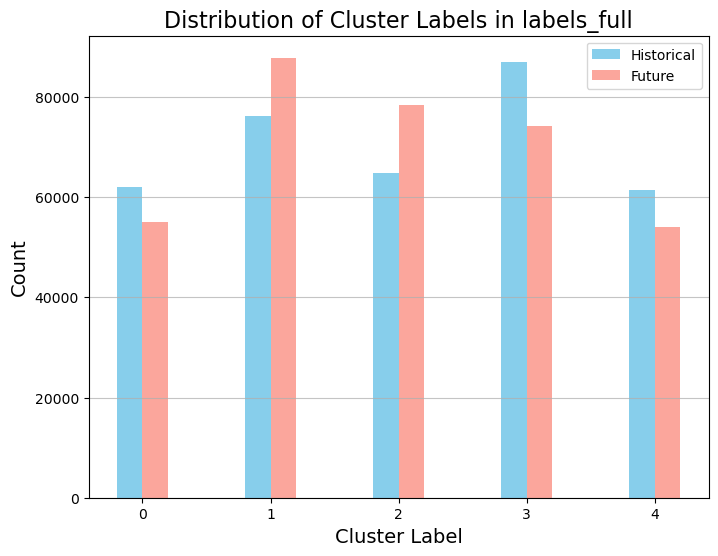

In [19]:

values, counts = np.unique(labels[~np.isnan(labels)], return_counts=True)

values_fut, counts_fut = np.unique(labels_fut_1d[~np.isnan(labels_fut_1d)], return_counts=True)

print(dict(zip(values, counts)))
print(dict(zip(values_fut, counts_fut)))

# Plot a histogram of the values in labels_full
plt.figure(figsize=(8, 6))
plt.bar(values, counts, color='skyblue', width=-0.2, align='edge', label='Historical')
plt.bar(values_fut, counts_fut, color='salmon', width=0.2, align='edge', alpha=0.7, label='Future')
plt.xlabel('Cluster Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of Cluster Labels in labels_full', fontsize=16)
plt.xticks(values)
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

In [20]:
# Convert to dataframe with time, ESM_run, and cluster_id columns
df = labels_da.to_dataframe(name="cluster").reset_index()# Remove crs, gridtype columns

# df = df.drop(columns=['crs', 'gridtype'])
# Remove rows where cluster is NaN
df = df.dropna(subset=['cluster'])
# Make cluster an integer
df['cluster'] = df['cluster'].astype(int)
df
df['ESM'] = df['ESM_run'].str.split('_').str[0]
df['run'] = df['ESM_run'].str.split('_').str[1]
# Change df['time'] to datetime
df['time'] = pd.to_datetime(df['time'].values.astype('datetime64[ns]'))
df['dayofyear'] = df['time'].dt.dayofyear
df

# ────────────── 4) Map each date → its meteorological season ──────────────

def month_to_season(m):
    # Meteorological seasons in the northern hemisphere:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:  # 9,10,11
        return "SON"

# Extract month from each timestamp, then map to season:
df["month"] = df["time"].apply(lambda x: x.month)
df['year'] = df["time"].apply(lambda x: x.year)
df["season"] = df["month"].map(month_to_season)

# ────────────── 5) Count how many samples of each cluster fall in each Month ──────────────

# This gives you a table with index = cluster ID, columns = month, and counts = number of samples.
monthly_counts = (
    df
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)

# If you want fractions instead of raw counts, you can do:
monthly_frac = monthly_counts.div(monthly_counts.sum(axis=0), axis=1)

# ────────────── 6) Count how many samples of each cluster fall in each year ──────────────
yearly_counts = (
    df
    .groupby(["cluster", df["year"]])
    .size()
    .unstack(fill_value=0)
)
# If you want fractions instead of raw counts, you can do:
yearly_frac = yearly_counts.div(yearly_counts.sum(axis=0), axis=1)

# ────────────── 7) Count how many samples of each cluster fall in each doy ──────────────
doy_counts = (
    df
    .groupby(["cluster", df["dayofyear"]])
    .size()
    .unstack(fill_value=0)
)
# If you want fractions instead of raw counts, you can do:
doy_frac = doy_counts.div(doy_counts.sum(axis=0), axis=1)

# ────────────── 7) Count samples of each cluster overall ──────────────
cluster_counts = df['cluster'].value_counts()


# Same for the future data
# Convert to dataframe with time, ESM_run, and cluster_id columns
df_fut = labels_fut.to_dataframe(name="cluster").reset_index()# Remove crs, gridtype columns

# df = df.drop(columns=['crs', 'gridtype'])
# Remove rows where cluster is NaN
df_fut = df_fut.dropna(subset=['cluster'])
# Make cluster an integer
df_fut['cluster'] = df_fut['cluster'].astype(int)
df_fut
df_fut['ESM'] = df_fut['ESM_run'].str.split('_').str[0]
df_fut['run'] = df_fut['ESM_run'].str.split('_').str[1]
# Change df_fut['time'] to datetime
df_fut['time'] = pd.to_datetime(df_fut['time'].values.astype('datetime64[ns]'))
df_fut['dayofyear'] = df_fut['time'].dt.dayofyear
df_fut

# ────────────── 4) Map each date → its meteorological season ──────────────

# Extract month from each timestamp, then map to season:
df_fut["month"] = df_fut["time"].apply(lambda x: x.month)
df_fut['year'] = df_fut["time"].apply(lambda x: x.year)
df_fut["season"] = df_fut["month"].map(month_to_season)

# ────────────── 5) Count how many samples of each cluster fall in each Month ──────────────

# This gives you a table with index = cluster ID, columns = month, and counts = number of samples.
monthly_counts_fut = (
    df_fut
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)

# If you want fractions instead of raw counts, you can do:
monthly_frac_fut = monthly_counts_fut.div(monthly_counts_fut.sum(axis=0), axis=1)

# ────────────── 6) Count how many samples of each cluster fall in each year ──────────────
yearly_counts_fut = (
    df_fut
    .groupby(["cluster", df_fut["year"]])
    .size()
    .unstack(fill_value=0)
)
# If you want fractions instead of raw counts, you can do:
yearly_frac_fut = yearly_counts_fut.div(yearly_counts_fut.sum(axis=0), axis=1)

# ────────────── 7) Count how many samples of each cluster fall in each doy ──────────────
doy_counts_fut = (
    df_fut
    .groupby(["cluster", df_fut["dayofyear"]])
    .size()
    .unstack(fill_value=0)
)
# If you want fractions instead of raw counts, you can do:
doy_frac_fut = doy_counts_fut.div(doy_counts_fut.sum(axis=0), axis=1)

# ────────────── 7) Count samples of each cluster overall ──────────────
cluster_counts_fut = df_fut['cluster'].value_counts()




In [21]:
df_fut["time"] = pd.to_datetime(df_fut["time"])
LEE_dat_fut["date_start"] = pd.to_datetime(LEE_dat_fut["date_start"])

df_fut = df_fut.merge(
    LEE_dat_fut[["ESM_run", "date_start", "RL_mean"]],
    left_on=["ESM_run", "time"],
    right_on=["ESM_run", "date_start"],
    how="left"
).drop(columns="date_start")

In [22]:
df["time"] = pd.to_datetime(df["time"])
LEE_dat["date_start"] = pd.to_datetime(LEE_dat["date_start"])

df = df.merge(
    LEE_dat[["ESM_run", "date_start", "RL_mean"]],
    left_on=["ESM_run", "time"],
    right_on=["ESM_run", "date_start"],
    how="left"
).drop(columns="date_start")

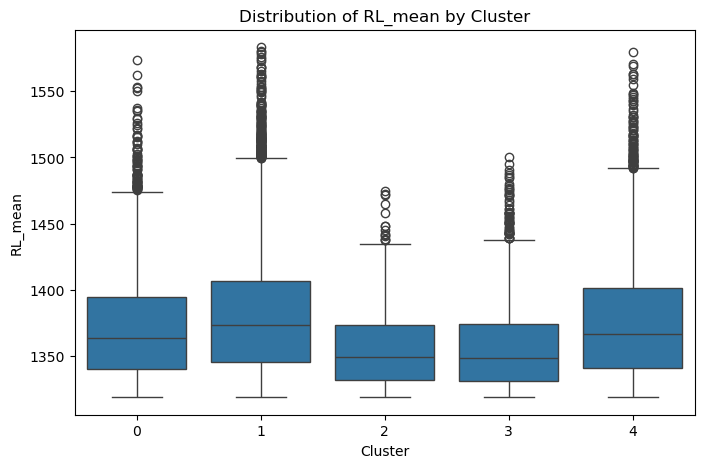

           count         mean        std          min          25%  \
cluster                                                              
0         5035.0  1371.348991  38.951932  1319.151541  1340.664108   
1        19050.0  1379.665147  42.125716  1319.140514  1345.632438   
2          795.0  1356.233537  29.978419  1319.157480  1332.256084   
3         2413.0  1357.135762  32.134957  1319.163179  1331.703305   
4         7924.0  1375.010729  41.800237  1319.147540  1340.963182   

                 50%          75%          max  
cluster                                         
0        1363.723911  1394.458419  1573.710221  
1        1373.248729  1407.162765  1583.105372  
2        1349.622192  1373.448493  1474.528780  
3        1348.779268  1374.461510  1500.188852  
4        1367.088022  1401.400443  1579.708167  


In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="cluster", y="RL_mean")
plt.xlabel("Cluster")
plt.ylabel("RL_mean")
plt.title("Distribution of RL_mean by Cluster")
plt.show()

# Print summary statistics of RL_mean for each cluster
summary_stats = df.groupby("cluster")["RL_mean"].describe()
print(summary_stats)

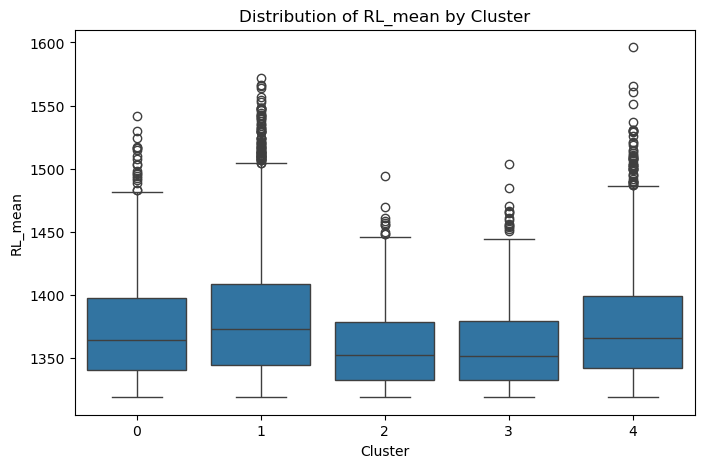

          count         mean        std          min          25%  \
cluster                                                             
0        1670.0  1373.518613  40.955554  1319.218492  1341.098433   
1        8096.0  1380.665716  44.194898  1319.179361  1344.617886   
2         432.0  1360.077768  32.833121  1319.242198  1332.887742   
3         688.0  1360.170862  33.307604  1319.218881  1332.515753   
4        2614.0  1375.043274  42.462349  1319.183836  1341.971121   

                 50%          75%          max  
cluster                                         
0        1364.343503  1397.650707  1541.807067  
1        1373.172632  1408.560558  1572.130186  
2        1352.639315  1378.641136  1494.522604  
3        1351.863809  1379.573172  1503.472349  
4        1366.419367  1399.625072  1596.223514  


In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_fut, x="cluster", y="RL_mean")
plt.xlabel("Cluster")
plt.ylabel("RL_mean")
plt.title("Distribution of RL_mean by Cluster")
plt.show()
# Print summary statistics of RL_mean for each cluster
summary_stats = df_fut.groupby("cluster")["RL_mean"].describe()
print(summary_stats)

In [25]:
cluster_counts

cluster
3    86892
1    76107
2    64769
0    62075
4    61417
Name: count, dtype: int64

In [26]:
cluster_counts_fut

cluster
1    87825
2    78316
3    74102
0    55073
4    54124
Name: count, dtype: int64

In [27]:
perc = (cluster_counts / cluster_counts.sum() *100).sort_index().round(2)
print(perc)
perc_fut = (cluster_counts_fut / cluster_counts_fut.sum() *100).sort_index().round(2)
print(perc_fut)
perc_change = perc_fut - perc
print(perc_change)

cluster
0    17.67
1    21.67
2    18.44
3    24.74
4    17.48
Name: count, dtype: float64
cluster
0    15.76
1    25.13
2    22.41
3    21.21
4    15.49
Name: count, dtype: float64
cluster
0   -1.91
1    3.46
2    3.97
3   -3.53
4   -1.99
Name: count, dtype: float64


In [28]:
perc

cluster
0    17.67
1    21.67
2    18.44
3    24.74
4    17.48
Name: count, dtype: float64

In [29]:
print(cluster_counts.sort_index() - cluster_counts_fut.sort_index())
# Calculate percentage change from historical to future for each cluster
percentage_change = ((cluster_counts_fut - cluster_counts) / cluster_counts) * 100
print(percentage_change.sort_index())

cluster
0     7002
1   -11718
2   -13547
3    12790
4     7293
Name: count, dtype: int64
cluster
0   -11.279903
1    15.396744
2    20.915870
3   -14.719422
4   -11.874562
Name: count, dtype: float64


In [30]:
# # Convert to dataframe with time, ESM_run, and cluster_id columns
# df_all = cluster_da.to_dataframe(name="cluster").reset_index()# Remove crs, gridtype columns

# # df_all = df_all.drop(columns=['crs', 'gridtype'])
# # Remove rows where cluster is NaN
# df_all = df_all.dropna(subset=['cluster'])
# # Make cluster an integer
# df_all['cluster'] = df_all['cluster'].astype(int)
# df_all
# df_all['ESM'] = df_all['ESM_run'].str.split('_').str[0]
# df_all['run'] = df_all['ESM_run'].str.split('_').str[1]
# # Change df_all['time'] to datetime
# df_all['time'] = pd.to_datetime(df_all['time'].values.astype('datetime64[ns]'))
# df_all['dayofyear'] = df_all['time'].dt.dayofyear
# df_all

# # ────────────── 4) Map each date → its meteorological season ──────────────

# # Extract month from each timestamp, then map to season:
# df_all["month"] = df_all["time"].apply(lambda x: x.month)
# df_all['year'] = df_all["time"].apply(lambda x: x.year)
# df_all["season"] = df_all["month"].map(month_to_season)

# # ────────────── 5) Count how many samples of each cluster fall in each Month ──────────────

# # This gives you a table with index = cluster ID, columns = month, and counts = number of samples.
# monthly_counts_all = (
#     df_all
#     .groupby(["cluster", "month"])
#     .size()
#     .unstack(fill_value=0)
# )

# # If you want fractions instead of raw counts, you can do:
# monthly_frac_all = monthly_counts_all.div(monthly_counts_all.sum(axis=0), axis=1)

# # ────────────── 6) Count how many samples of each cluster fall in each year ──────────────
# yearly_counts_all = (
#     df_all
#     .groupby(["cluster", df_all["year"]])
#     .size()
#     .unstack(fill_value=0)
# )
# # If you want fractions instead of raw counts, you can do:
# yearly_frac_all = yearly_counts_all.div(yearly_counts_all.sum(axis=0), axis=1)

# # ────────────── 7) Count how many samples of each cluster fall in each doy ──────────────
# doy_counts_all = (
#     df_all
#     .groupby(["cluster", df_all["dayofyear"]])
#     .size()
#     .unstack(fill_value=0)
# )
# # If you want fractions instead of raw counts, you can do:
# doy_frac_all = doy_counts_all.div(doy_counts_all.sum(axis=0), axis=1)

# # ────────────── 7) Count samples of each cluster overall ──────────────
# cluster_counts_all = df_all['cluster'].value_counts()


# # Same for the future data
# # Convert to dataframe with time, ESM_run, and cluster_id columns
# df_all_fut = cluster_da_fut.to_dataframe(name="cluster").reset_index()# Remove crs, gridtype columns

# # df_all = df_all.drop(columns=['crs', 'gridtype'])
# # Remove rows where cluster is NaN
# df_all_fut = df_all_fut.dropna(subset=['cluster'])
# # Make cluster an integer
# df_all_fut['cluster'] = df_all_fut['cluster'].astype(int)
# df_all_fut
# df_all_fut['ESM'] = df_all_fut['ESM_run'].str.split('_').str[0]
# df_all_fut['run'] = df_all_fut['ESM_run'].str.split('_').str[1]
# # Change df_all_fut['time'] to datetime
# df_all_fut['time'] = pd.to_datetime(df_all_fut['time'].values.astype('datetime64[ns]'))
# df_all_fut['dayofyear'] = df_all_fut['time'].dt.dayofyear
# df_all_fut

# # ────────────── 4) Map each date → its meteorological season ──────────────

# # Extract month from each timestamp, then map to season:
# df_all_fut["month"] = df_all_fut["time"].apply(lambda x: x.month)
# df_all_fut['year'] = df_all_fut["time"].apply(lambda x: x.year)
# df_all_fut["season"] = df_all_fut["month"].map(month_to_season)

# # ────────────── 5) Count how many samples of each cluster fall in each Month ──────────────

# # This gives you a table with index = cluster ID, columns = month, and counts = number of samples.
# monthly_counts_all_fut = (
#     df_all_fut
#     .groupby(["cluster", "month"])
#     .size()
#     .unstack(fill_value=0)
# )

# # If you want fractions instead of raw counts, you can do:
# monthly_frac_all_fut = monthly_counts_all_fut.div(monthly_counts_all_fut.sum(axis=0), axis=1)

# # ────────────── 6) Count how many samples of each cluster fall in each year ──────────────
# yearly_counts_all_fut = (
#     df_all_fut
#     .groupby(["cluster", df_all_fut["year"]])
#     .size()
#     .unstack(fill_value=0)
# )
# # If you want fractions instead of raw counts, you can do:
# yearly_frac_all_fut = yearly_counts_all_fut.div(yearly_counts_all_fut.sum(axis=0), axis=1)

# # ────────────── 7) Count how many samples of each cluster fall in each doy ──────────────
# doy_counts_all_fut = (
#     df_all_fut
#     .groupby(["cluster", df_all_fut["dayofyear"]])
#     .size()
#     .unstack(fill_value=0)
# )
# # If you want fractions instead of raw counts, you can do:
# doy_frac_all_fut = doy_counts_all_fut.div(doy_counts_all_fut.sum(axis=0), axis=1)

# # ────────────── 7) Count samples of each cluster overall ──────────────
# cluster_counts_all_fut = df_all_fut['cluster'].value_counts()


In [31]:
# # Remove ERA5 from df_all
# df_all_CMIP = df_all[~df_all['ESM'].str.contains('ERA5')]
# df_all_CMIP
# cluster_counts_all_CMIP = df_all_CMIP['cluster'].value_counts()
# cluster_counts_all_CMIP

In [32]:
# perc_all = (cluster_counts_all_CMIP / cluster_counts_all_CMIP.sum() *100).sort_index().round(2)
# print(perc_all)
# perc_all_fut = (cluster_counts_all_fut / cluster_counts_all_fut.sum() *100).sort_index().round(2)
# print(perc_all_fut)
# perc_change_all = perc_all_fut - perc_all
# print(perc_change_all)

In [33]:
# cluster_counts_all.sort_index()

In [34]:
# cluster_counts_all_fut.sort_index()

In [35]:
# (cluster_counts_all.sort_index() * percentage_change.sort_index())/ 100 #+ cluster_counts_all.sort_index()

In [36]:
# print(cluster_counts_all_CMIP.sort_index() - cluster_counts_all_fut.sort_index())
# # Calculate percentage change from historical to future for each cluster
# percentage_change = ((cluster_counts_all_fut - cluster_counts_all_CMIP) / cluster_counts_all_CMIP) * 100
# print(percentage_change.sort_index())

In [37]:
# cluster_counts_all_fut.sum()

In [38]:
# cluster_counts_all.sum() - cluster_counts_all_fut.sum()

In [39]:
# cluster_counts_all_fut.sum()

In [40]:
print(38568 - 38733) # Cluster 1
print(122338 - 121932) # Cluster 2
print(42933 - 41829) # Cluster 3
print(147421 - 146946) # Cluster 4

-165
406
1104
475


### Only cluster center maps

/tmp/ipykernel_4004226/1381767740.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


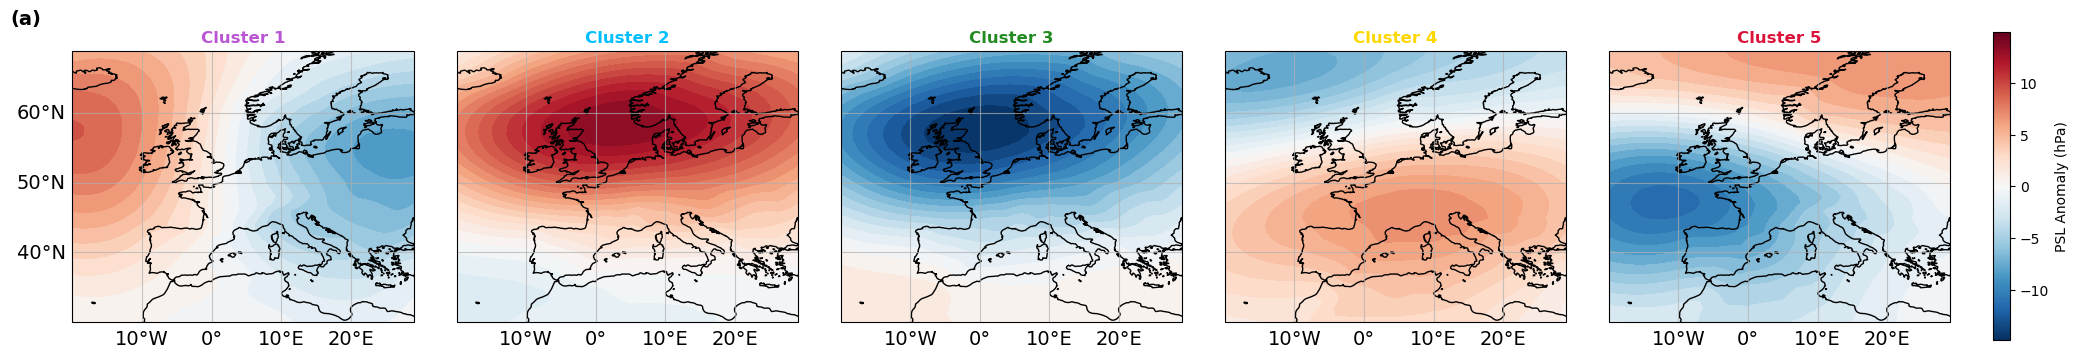

In [ ]:
# Define cluster title colors (match figure)
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]

# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(centroids_unweighted / 100.0)
vmax = -vmin # np.nanmax(centroids_unweighted / 100.0)

# 2) Decide on subplot grid
ncols = 5
nrows = 1

# 3) Create figure + GridSpec (extra col for colorbar)
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

lons = ((ts_datasets_filtered['lon'].values + 180) % 360) - 180
lats = ts_datasets_filtered['lat'].values

for i in range(5):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())

    # Plot with red-blue color scheme
    cf = ax.contourf(
        lons, lats, (centroids_unweighted[i, :, :] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()
    if i == 0:
        setup_gridlines(ax, deg=10, alpha=0.7)
    else:
        setup_gridlines(ax, deg=10, alpha=0.7, ll=False)

    ax.set_title(f"Cluster {i + 1}", fontsize=12, color=cluster_colors[i], fontweight='bold')

# 4) Add (a) label
fig.text(0.1, 0.9, "(a)", fontsize=14, fontweight='bold')

# 5) Create ScalarMappable for colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

# 6) Add vertical colorbar on the right
cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('SLP Anomaly (hPa)', fontsize=10)

plt.tight_layout()
plt.show()

### Calculate dates from events

In [42]:

LEE_dat["date_start"] = LEE_dat["date_start"].dt.strftime("%Y-%m-%d")
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35218,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1455.111286,1455.111286,0.0,1455.111286,35219,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,354
35219,2024-12-21,2024-12-21,2024-12-21,3639,3639,3639,1,1433.341128,1433.341128,0.0,1433.341128,35220,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,355
35220,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1392.939718,1392.939718,0.0,1392.939718,35221,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,359
35221,2024-12-30,2024-12-30,2024-12-30,3648,3648,3648,1,1506.619573,1506.619573,0.0,1506.619573,35222,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,364


In [43]:
LEE_dat_dl = create_date_list(LEE_dat, labels_da)
LEE_7_dl = create_date_list(LEE_7, labels_da)
LEE_14_dl = create_date_list(LEE_14, labels_da)

In [44]:
LEE_dat_dl['Cluster'].value_counts()

Cluster
1    19050
4     7924
0     5035
3     2413
2      795
Name: count, dtype: int64

In [45]:
LEE_dat_fut["date_start"] = LEE_dat_fut["date_start"].dt.strftime("%Y-%m-%d")


In [46]:
labels_fut.ESM_run.values[0]

np.str_('ACCESS-CM2_r4i1p1f1')

In [47]:
new_esm_runs = []
for esm_run in labels_fut.ESM_run.values:
    s = str(esm_run)
    if s.split('_')[1] == 'LE':
        new_esm_runs.append(s.split('_')[0] + '_' + s.split('_')[2] + '_' + s.split('_')[3])
    else:
        new_esm_runs.append(s)

labels_fut = labels_fut.assign_coords(ESM_run=new_esm_runs)

In [48]:
LEE_dat_dl_fut = create_date_list(LEE_dat_fut, labels_fut)
LEE_7_dl_fut = create_date_list(LEE_7_fut, labels_fut)
LEE_14_dl_fut = create_date_list(LEE_14_fut, labels_fut)

# Change the 'Cluster' column to integer type
LEE_dat_dl_fut['Cluster'] = LEE_dat_dl_fut['Cluster'].astype(int)
LEE_7_dl_fut['Cluster'] = LEE_7_dl_fut['Cluster'].astype(int)
LEE_14_dl_fut['Cluster'] = LEE_14_dl_fut['Cluster'].astype(int)

### Plot for event days distributions of cluster for different event lengths

In [49]:
# Compute relative frequencies for each DataFrame
dfs = {
    'Daily': pd.DataFrame(LEE_dat_dl),
    '7-day': pd.DataFrame(LEE_7_dl),
    '14-day': pd.DataFrame(LEE_14_dl)
}

# Get sorted list of all clusters present across datasets
all_clusters = sorted(set().union(*(df['Cluster'].unique() for df in dfs.values())))

# Prepare proportions matrix
data = {
    name: df['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df in dfs.items()
}

# Same for the future data
# Compute relative frequencies for each DataFrame
dfs_fut = {
    'Daily': pd.DataFrame(LEE_dat_dl_fut),
    '7-day': pd.DataFrame(LEE_7_dl_fut),
    '14-day': pd.DataFrame(LEE_14_dl_fut)
}

# Get sorted list of all clusters present across datasets
all_clusters_fut = sorted(set().union(*(df['Cluster'].unique() for df in dfs_fut.values())))

# Prepare proportions matrix
data_fut = {
    name: df['Cluster'].value_counts(normalize=True).reindex(all_clusters_fut, fill_value=0)
    for name, df in dfs_fut.items()
}


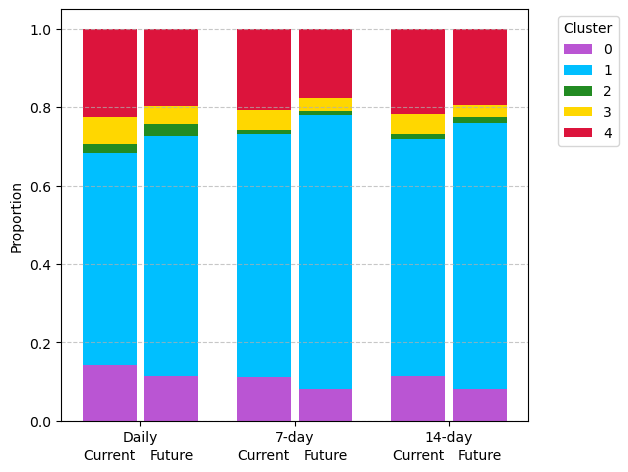

In [50]:
# Plotting
fig, ax = plt.subplots()
bar_width = 0.35  # Width of each bar
intra_group_spacing = 0.2  # Space between bars within a group
x = np.arange(len(dfs))  # Center positions for each group

# Plot current climate bars (left in each group)
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    ax.bar(x - intra_group_spacing, heights, bar_width, align='center', bottom=bottom, label=f'{cluster}', color=cluster_colors[cluster])
    bottom += heights

# Plot future climate bars (right in each group)
bottom_fut = np.zeros(len(dfs_fut))
for cluster in all_clusters_fut:
    heights = [data_fut[name].get(cluster, 0) for name in dfs_fut]
    ax.bar(x + intra_group_spacing, heights, bar_width, align='center', bottom=bottom_fut, color=cluster_colors[cluster])
    bottom_fut += heights

# Add x-axis labels for current and future climate
for xi in x:
    ax.text(xi - intra_group_spacing, -0.07, 'Current',
            ha='center', va='top', transform=ax.transData)
    ax.text(xi + intra_group_spacing, -0.07, 'Future',
            ha='center', va='top', transform=ax.transData)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dfs.keys())
ax.set_ylabel('Proportion')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [51]:
heights

[np.float64(0.1972769775082133),
 np.float64(0.17746861214794707),
 np.float64(0.19394512771996217)]

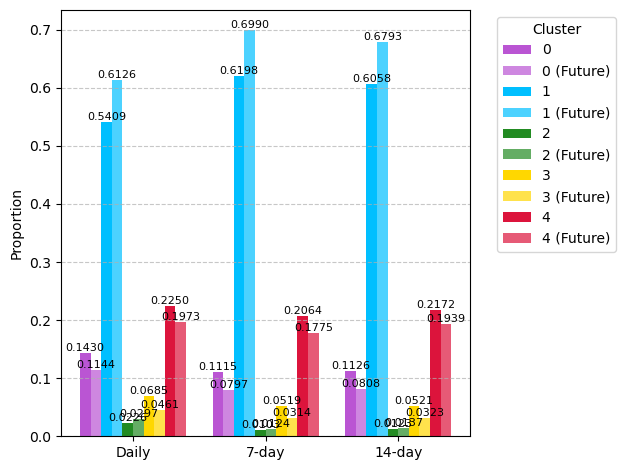

In [52]:
# Plotting
fig, ax = plt.subplots()
num_clusters = len(all_clusters)
bar_width = 0.8 / (2 * num_clusters)  # Half the width, since we interleave

x = np.arange(len(dfs))  # positions for the main groups

# Plot interleaved bars
for i, cluster in enumerate(all_clusters):
    # Current climate bars
    heights = [data[name].get(cluster, 0) for name in dfs]
    offset_x = x + (2 * i) * bar_width - (bar_width * (2 * num_clusters - 1) / 2)
    bars = ax.bar(offset_x, heights, bar_width, label=str(cluster), color=cluster_colors[cluster])
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    # Future climate bars
    heights_fut = [data_fut[name].get(cluster, 0) for name in dfs_fut]
    offset_x_fut = x + (2 * i + 1) * bar_width - (bar_width * (2 * num_clusters - 1) / 2)
    bars_fut = ax.bar(offset_x_fut, heights_fut, bar_width, label=f'{cluster} (Future)', color=cluster_colors[cluster], alpha=0.7)
    for bar in bars_fut:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dfs.keys())
ax.set_ylabel('Proportion')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Plot clusters against ESM

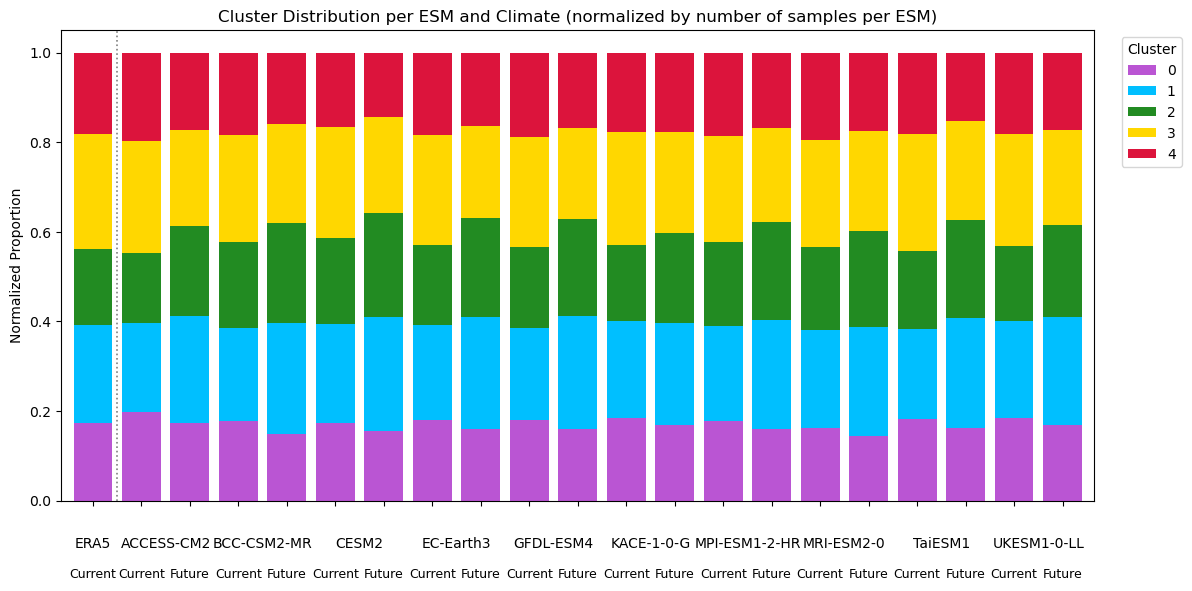

In [53]:
# Calculate the number of samples per ESM
samples_per_esm = df['ESM'].value_counts()
samples_per_esm = samples_per_esm / samples_per_esm.sum()

samples_per_esm_fut = df_fut['ESM'].value_counts()
samples_per_esm_fut = samples_per_esm_fut / samples_per_esm_fut.sum()

# Group by ESM and cluster, then count occurrences
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_counts = esm_cluster_counts.div(esm_cluster_counts.sum(axis=1), axis=0)

esm_cluster_counts_fut = df_fut.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_counts_fut = esm_cluster_counts_fut.div(esm_cluster_counts_fut.sum(axis=1), axis=0)

# Combine current and future data
esm_cluster_counts['Climate'] = 'Current'
esm_cluster_counts_fut['Climate'] = 'Future'
combined = pd.concat([esm_cluster_counts, esm_cluster_counts_fut])

# Reshape for plotting
combined = combined.reset_index().melt(id_vars=['ESM', 'Climate'], var_name='cluster', value_name='proportion')

# Create a new column for ESM + Climate to interleave
combined['ESM_Climate'] = combined['ESM'] + '_' + combined['Climate']
combined = combined.sort_values(['ESM', 'Climate'])

# Pivot for stacked bar plot
plot_data = combined.pivot(index='ESM_Climate', columns='cluster', values='proportion').fillna(0)

# Get the order for interleaving: Current, Future, Current, Future, ...
esms = sorted(combined['ESM'].unique())
order = []
order.append("ERA5_Current")
for esm in esms:
    if esm == "ERA5":
        continue
    order.append(f"{esm}_Current")
    order.append(f"{esm}_Future")
plot_data = plot_data.reindex(order)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
plot_data.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=cluster_colors,
    width=0.8
)

ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.2, zorder=10)

# Customize x-axis labels
ax.set_xticks(range(len(order)))
ax.set_xticklabels(['' for _ in order])  # Hide default x-tick labels

# Add ESM labels (centered under each pair of bars)
esm_positions = []
f = 0
for i, esm in enumerate(esms):
    if esm == "ERA5":
        esm_positions.append(0)
        f = - 2
        # continue
    else:
        esm_positions.append(2*i +1.5 + f)
    ax.text(esm_positions[-1], -0.08, esm, ha='center', va='top', fontsize=10)

# Add Current/Future labels (below each bar)
for i, label in enumerate(order):
    climate = label.split('_')[1]
    ax.text(i, -0.15, climate, ha='center', va='top', fontsize=9)

ax.set_xlabel("")
ax.set_ylabel("Normalized Proportion")
ax.set_title("Cluster Distribution per ESM and Climate (normalized by number of samples per ESM)")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Large Plot combined

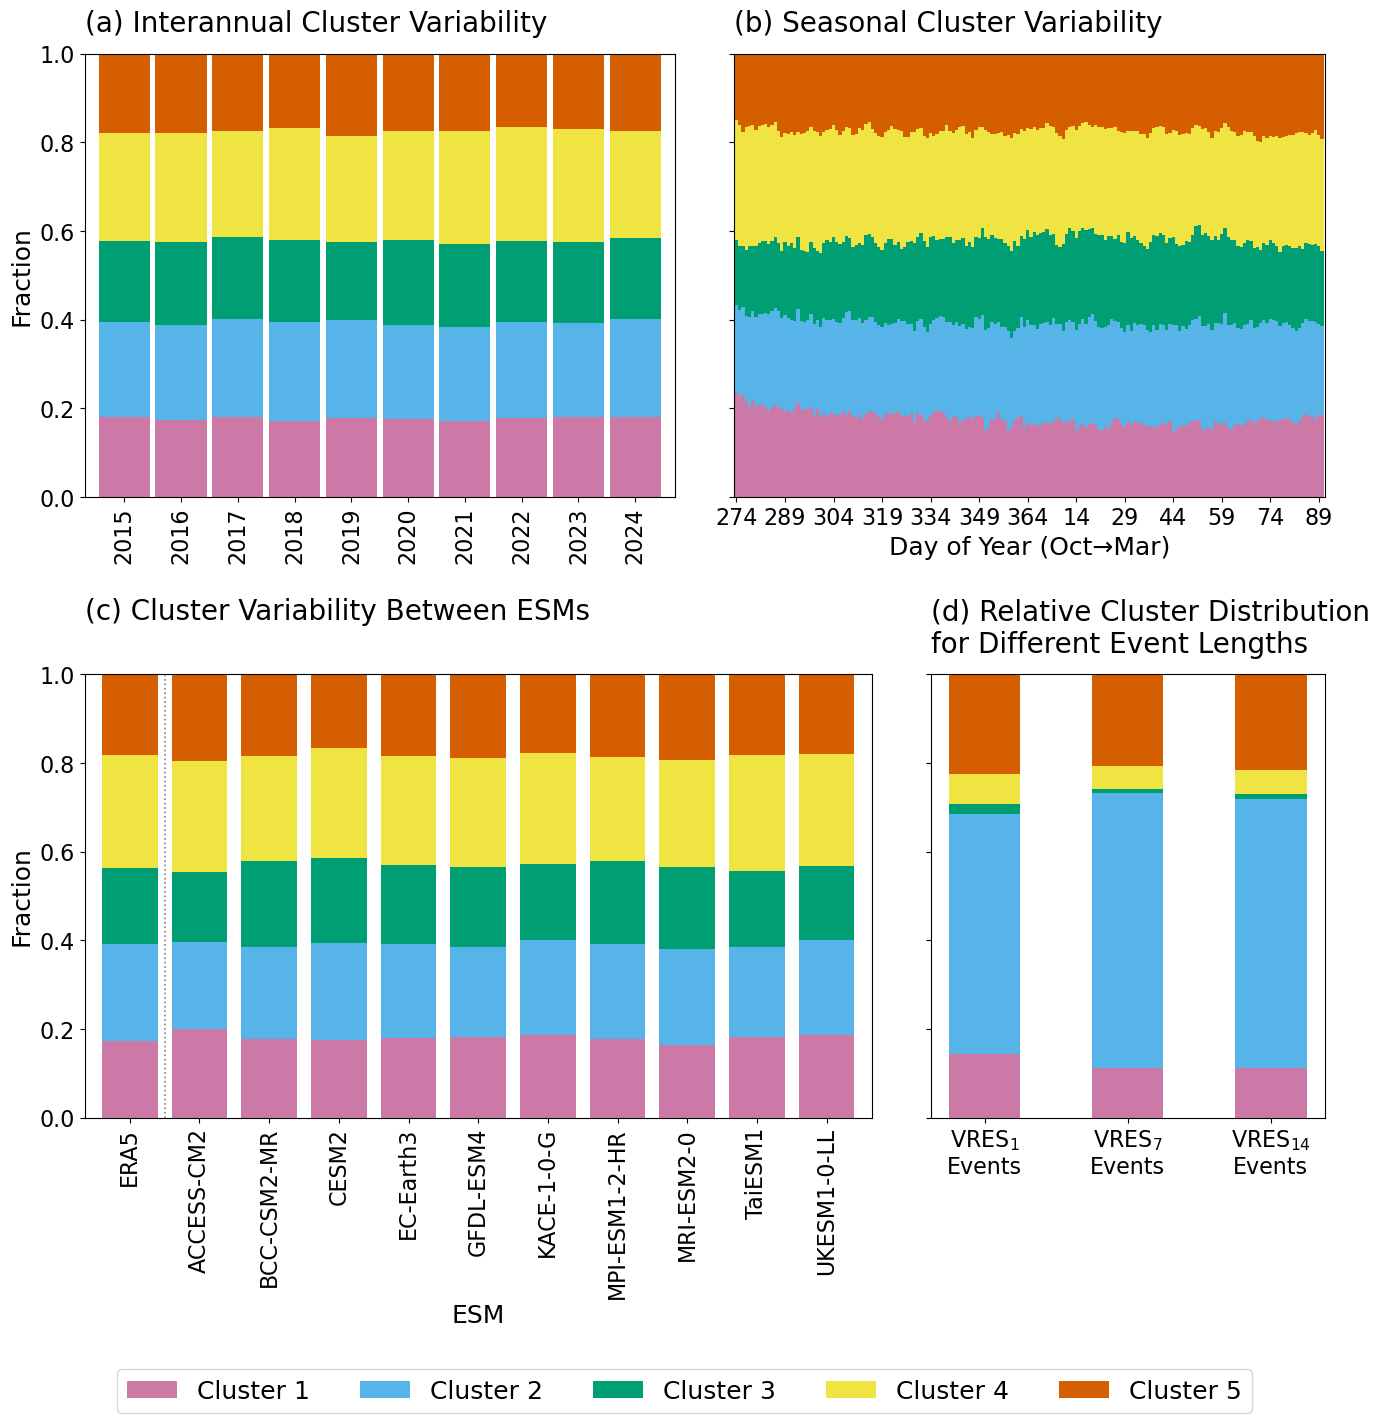

In [54]:
mpl.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 18,
    'figure.titlesize': 20,
})
plt.rcParams['axes.titlepad'] = 16  # default padding for all titles (in points)

# --- palette (re-use your colors) ---
# cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
# colorblind-friendly hex colours (Okabe–Ito subset)
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]

cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# Create 2x2 figure
fig = plt.figure(figsize=(16, 14))
# gs = GridSpec(2, 2, figure=fig, hspace=0.2, wspace=0.1)
outer = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.4)  # hspace adjusts the vertical space between the two rows

top = outer[0].subgridspec(1, 2, wspace=0.1)
ax_a = fig.add_subplot(top[0, 0])  # (b) links
ax_b = fig.add_subplot(top[0, 1])  # (c) rechts

# --------------------------
# (a) Top-left: Yearly fractions (stacked bar)
# --------------------------
# ax_a = fig.add_subplot(gs[0, 0])
df_year = yearly_frac.T  # as in your original code

df_year.plot(
    kind="bar", stacked=True, ax=ax_a, width=0.9,
    color=[cluster_palette[int(c)] for c in df_year.columns],
    legend=False
)
ax_a.set_xlabel("")
ax_a.set_ylabel("Fraction")
ax_a.set_ylim(0, 1)
ax_a.set_xticklabels(df_year.index, rotation=90) # , ha="right"
# ax_a.set_title("(a) Yearly fractions", fontsize=20, fontweight='bold', loc='left')
ax_a.set_title("(a) Interannual Cluster Variability", fontsize=20, loc='left')

# --------------------------
# (b) Bottom-left: simple cluster counts bar (replaces the maps)
# --------------------------
# ax_b = fig.add_subplot(gs[0, 1])
days = doy_frac.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=ax_b, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
ax_b.set_xlabel("Day of Year (Oct→Mar)")
ax_b.set_ylabel("")
# ax_b.set_ylabel("Fraction")
ax_b.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
ax_b.set_xticks(ticks)
ax_b.set_xticklabels(df_doy.index[ticks], rotation=0) #, ha="right"
ax_b.set_yticklabels([])
# fig.text(0.39, 0.57, "(b)", fontsize=20, fontweight="bold")
ax_b.set_title("(b) Seasonal Cluster Variability", fontsize=20, loc='left')


bottom = outer[1].subgridspec(1, 2, width_ratios=[2, 1], wspace=0.1)
ax_c = fig.add_subplot(bottom[0, 0])  # (c) nimmt 2/3 Breite
ax_d = fig.add_subplot(bottom[0, 1])  # (d) nimmt 1/3 Breite
# --------------------------
# (c) Top-right: ESM stacked bar normalized per-ESM
# --------------------------
# ax_c = fig.add_subplot(gs[1, 0])

# Prepare ESM x cluster counts and normalize per ESM to get fractions
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)

# normalize rows so each ESM's stacked bar sums to 1 (fractions per ESM)
esm_cluster_props = esm_cluster_counts.div(esm_cluster_counts.sum(axis=1), axis=0)

# order cluster columns (in case some cluster numbers missing)
ordered_clusters = sorted(esm_cluster_props.columns.astype(int))
esm_cluster_props = esm_cluster_props[ordered_clusters]

# color list matching the ordered clusters
colors_for_esm = [cluster_palette[int(c)] for c in ordered_clusters]

# --- bring ERA5 (case-insensitive) to the front if present ---
era_row = None
for idx in esm_cluster_props.index:
    if 'era' in str(idx).lower():   # findet 'ERA5', 'era5', 'ERA-5', 'era_5' etc.
        era_row = idx
        break

new_order = [era_row] + [i for i in esm_cluster_props.index if i != era_row]
esm_to_plot = esm_cluster_props.loc[new_order]

# plot
esm_to_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax_c,
    width=0.8,
    color=colors_for_esm,
    legend=False
)
ax_c.set_xlabel("ESM")
ax_c.set_ylabel("Fraction")
ax_c.set_ylim(0, 1)
ax_c.set_title("(c) Cluster Variability Between ESMs\n", fontsize=20, loc='left')

# rotate xticks vertically for readability
ax_c.set_xticklabels(ax_c.get_xticklabels(), rotation=90)

# draw vertical grey dotted separator after the first bar if ERA was moved to front
# Bars are centered at x = 0,1,2,... so separator between first and second is at x = 0.5
sep_x = 0.5
ax_c.axvline(x=sep_x, color='gray', linestyle=':', linewidth=1.2, zorder=10)


# --------------------------
# (d) Bottom-right: relative cluster distribution for 1/7/14-day events (your original logic)
# --------------------------
# ax_d = fig.add_subplot(gs[1, 1])
dfs = {
    r'$\mathrm{VRES}_{1}$' + '\n' + 'Events': pd.DataFrame(LEE_dat_dl),
    r'$\mathrm{VRES}_{7}$' + '\n' + 'Events': pd.DataFrame(LEE_7_dl),
    r'$\mathrm{VRES}_{14}$' + '\n' + 'Events': pd.DataFrame(LEE_14_dl)
}

all_clusters = sorted(set().union(*(df_['Cluster'].unique() for df_ in dfs.values())))
data = {
    name: df_['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df_ in dfs.items()
}

bar_width = 0.5
x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    ax_d.bar(x, heights, bar_width, bottom=bottom, label=f"Cluster {int(cluster)+1}", color=cluster_palette[int(cluster)])
    bottom += heights

ax_d.set_xticks(x)
ax_d.set_xticklabels(list(dfs.keys()), rotation=0)
ax_d.set_yticklabels([])
ax_d.set_ylabel('')
ax_d.set_ylim(0, 1)
# ax_d.set_title("(d) Relative cluster distribution (1/7/14-day)", fontsize=20, loc='left')
ax_d.set_title("(d) Relative Cluster Distribution \nfor Different Event Lengths", fontsize=20, loc='left')

# --------------------------
# Global legend (lower center) using consistent cluster handles
# --------------------------
legend_handles = [
    Patch(facecolor=cluster_palette[int(c)], label=f"Cluster {int(c)+1}")
    for c in all_clusters
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, -0.1),
    frameon=True
)

# final layout tweak and show
fig.subplots_adjust(bottom=0.12)
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_2x2.png', dpi=300, bbox_inches='tight')

plt.show()


In [55]:
cluster_counts

cluster
3    86892
1    76107
2    64769
0    62075
4    61417
Name: count, dtype: int64

/tmp/ipykernel_4004226/1381767740.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


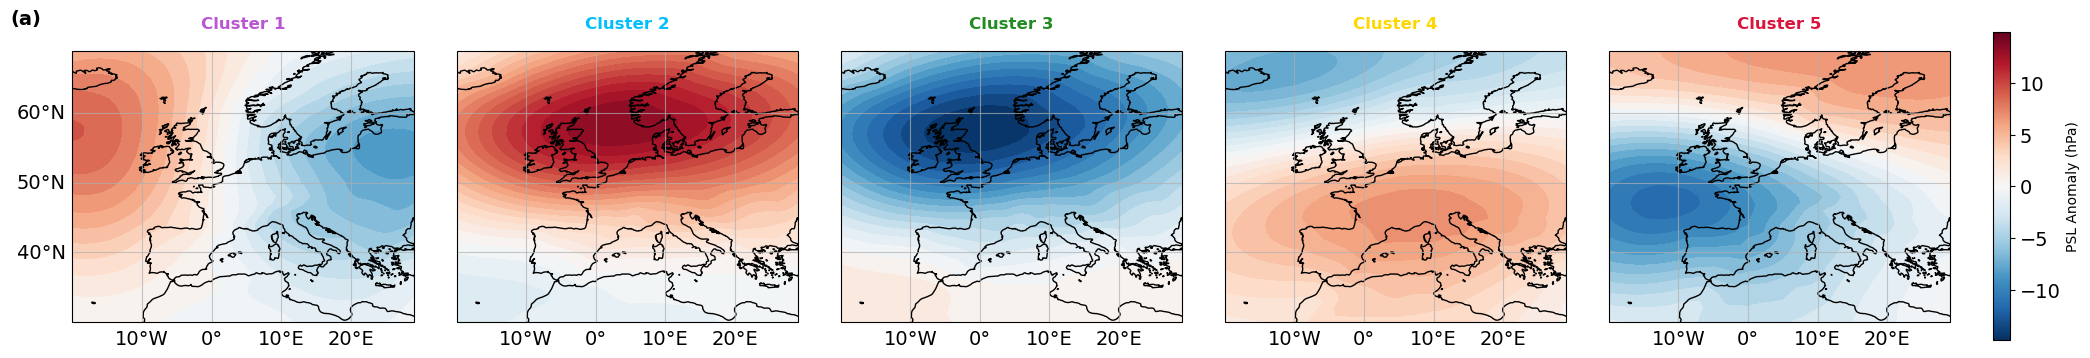

In [ ]:
# Define cluster title colors (match figure)
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]

# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(centroids_unweighted / 100.0)
vmax = -vmin # np.nanmax(centroids_unweighted / 100.0)

# 2) Decide on subplot grid
ncols = 5
nrows = 1

# 3) Create figure + GridSpec (extra col for colorbar)
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

lons = ((ts_datasets_filtered['lon'].values + 180) % 360) - 180
lats = ts_datasets_filtered['lat'].values

for i in range(5):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())

    # Plot with red-blue color scheme
    cf = ax.contourf(
        lons, lats, (centroids_unweighted[i, :, :] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()
    if i == 0:
        setup_gridlines(ax, deg=10, alpha=0.7)
    else:
        setup_gridlines(ax, deg=10, alpha=0.7, ll=False)

    ax.set_title(f"Cluster {i + 1}", fontsize=12, color=cluster_colors[i], fontweight='bold')

# 4) Add (a) label
fig.text(0.1, 0.9, "(a)", fontsize=14, fontweight='bold')

# 5) Create ScalarMappable for colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

# 6) Add vertical colorbar on the right
cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('SLP Anomaly (hPa)', fontsize=10)

plt.tight_layout()
plt.show()

In [76]:
lon_edges_1 = ts_datasets.lon.values
lat_edges_1 = ts_datasets.lat.values
def setup_gridlines_big(ax, deg = 15, alpha = 0.4, ll = True, bl = True, label_size = 24):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.array([-20, 0, 20, 40]) # np.array([340, 360, 0, 20, 40]) # np.arange(lon_edges_1.min(), lon_edges_1.max() + deg, deg)
    yticks = np.arange(lat_edges_1.min() + 1, lat_edges_1.max() + deg, deg)
    # ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    # ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=18)

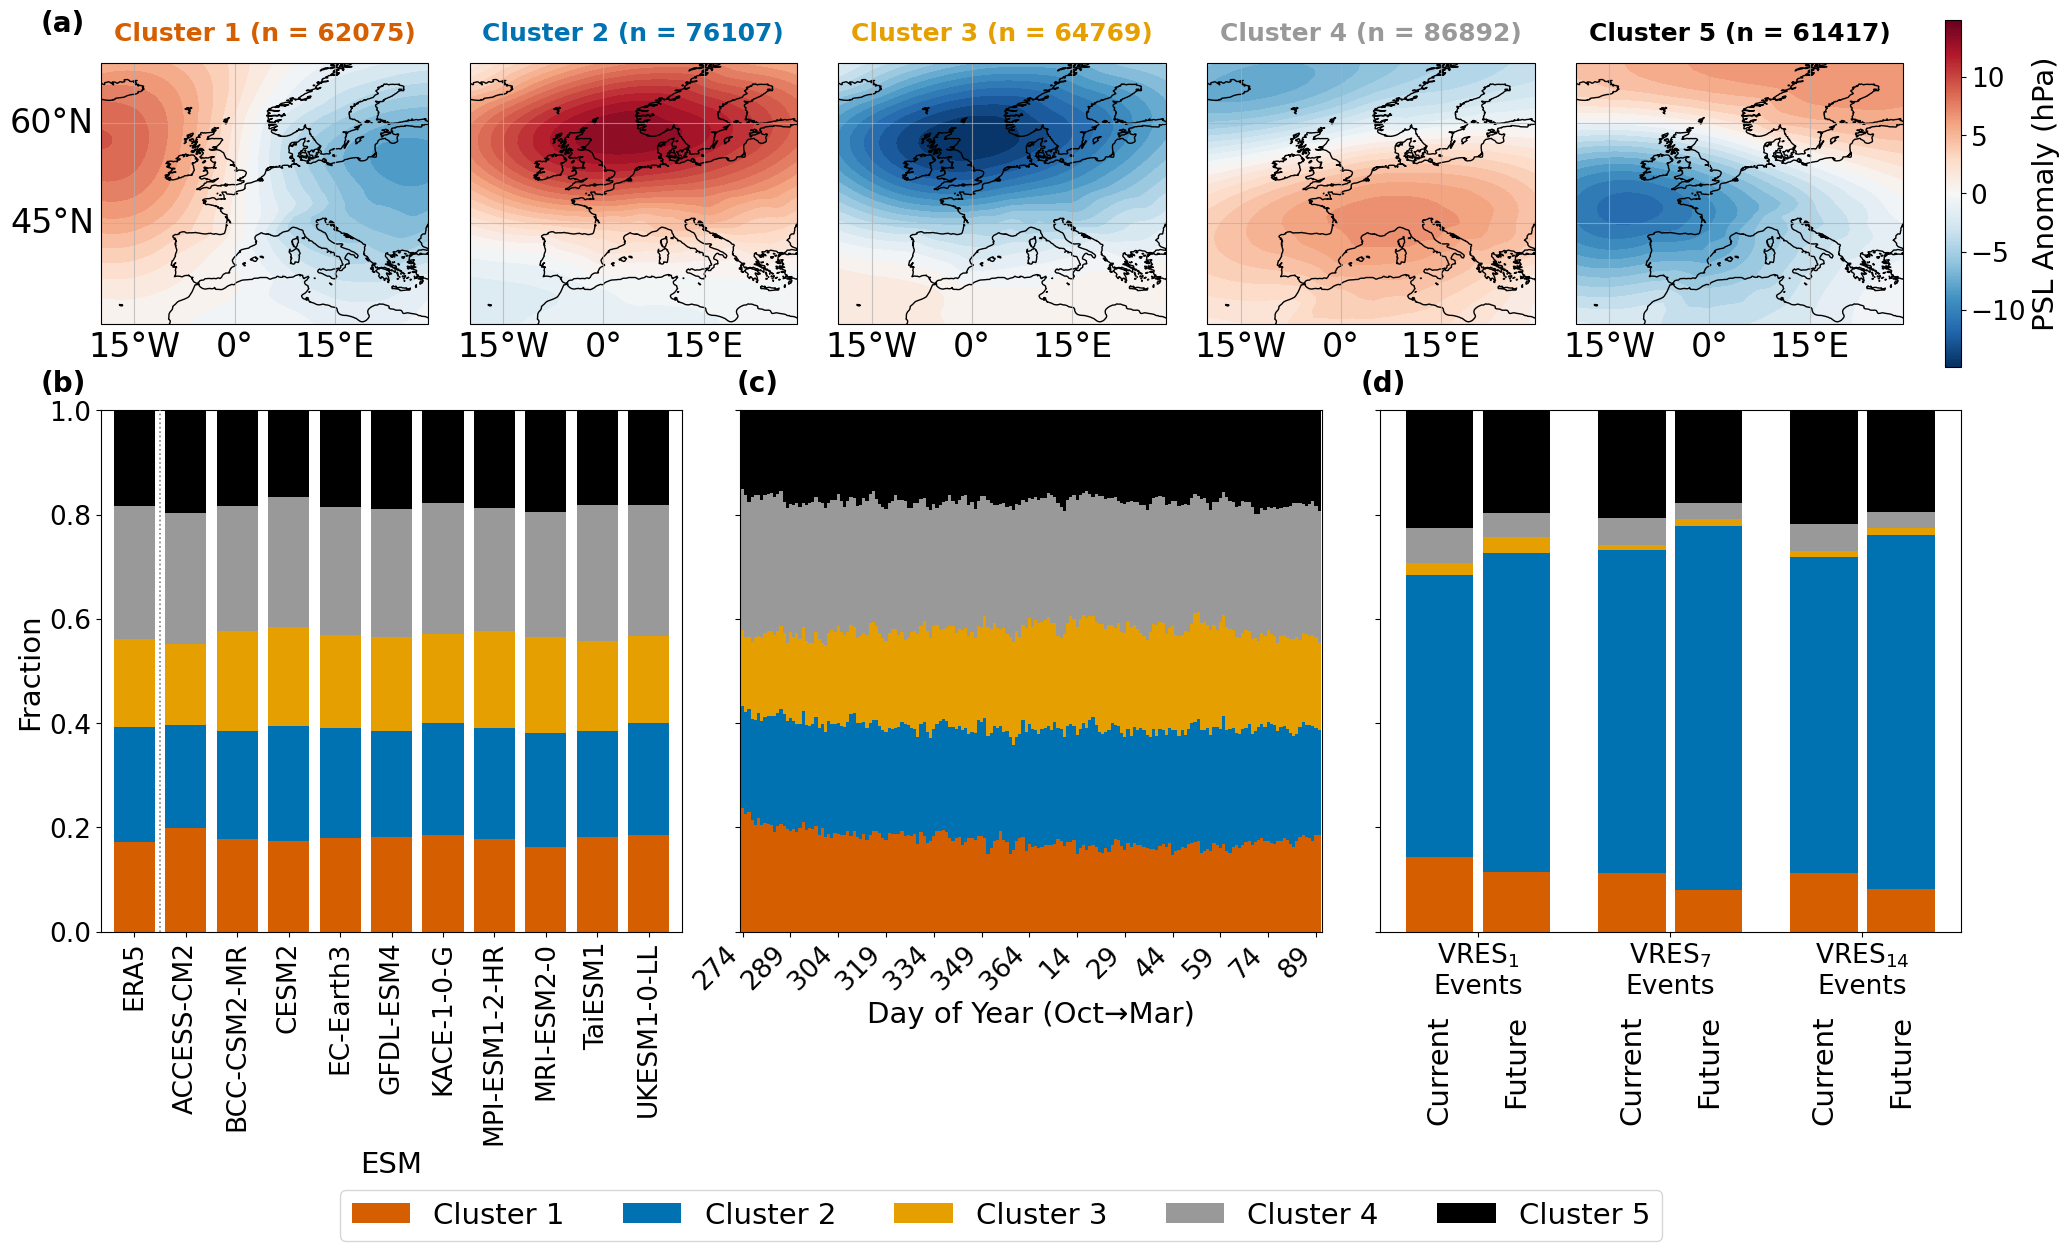

In [ ]:
# --- Make all text bigger (global defaults) ---
# mpl.rcParams.update({
#     'font.size': 16,           # base font size
#     'axes.titlesize': 18,      # axes titles
#     'axes.labelsize': 16,      # x/y labels
#     'xtick.labelsize': 14,     # x tick labels
#     'ytick.labelsize': 14,     # y tick labels
#     'legend.fontsize': 16,     # legend text
#     'figure.titlesize': 18,    # figure title (if used)
# })

mpl.rcParams.update({
    'font.size': 16+5,
    'axes.titlesize': 18+5,
    'axes.labelsize': 16+5,
    'xtick.labelsize': 14+5,
    'ytick.labelsize': 14+5,
    'legend.fontsize': 16+5,
    'figure.titlesize': 18+5,
})

# Create a color palette for clusters
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]
cluster_colors = [
    # "#CC79A7",  # purple
    # "#56B4E9",  # light blue
    # "#009E73",  # green
    # "#F0E442",  # yellow
    "#D55E00",  # orange-red
    "#0072B2",  # dark blue
    "#E69F00",  # orange
    "#999999",  # grey
    "#000000",  # black
]


cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# global vmin/vmax
vmin = np.nanmin(centroids_unweighted / 100.0)
vmax = -vmin

# create figure & top‐level 2×1 GridSpec
fig = plt.figure(figsize=(24, 12))                              # Adjust size of the figure
outer_gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.1)     # Create outer GridSpec with 2 rows, 1 column, and space between rows

# --- ROW 1: five maps + colorbar in a 1×5 sub‐GridSpec ---
row1 = outer_gs[0].subgridspec(1, 6, width_ratios=[1,1,1,1,1,0.05], wspace=0.15) # Create sub‐GridSpec for row 1 with 5 columns (5 maps + colorbar)
lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values
for i in range(5):  # Loop through each cluster                             # Plot each cluster in a separate subplot
    ax = fig.add_subplot(row1[0, i], projection=ccrs.PlateCarree())
    cf = ax.contourf(
        lons, lats, (centroids_unweighted[i] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    if i == 0:
        setup_gridlines_big(ax, label_size=24, alpha=0.7)
    else:
        setup_gridlines_big(ax, label_size=24, alpha=0.7, ll=False)
    ax.set_title(f"Cluster {i+1} (n = {cluster_counts[i]})", color=cluster_colors[i],
                 fontsize=18, fontweight='bold')   # increased title fontsize
    ax.tick_params()

# colorbar
tnorm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=tnorm, cmap=cf.cmap)
sm.set_array([])
cax = fig.add_subplot(row1[0, 5])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('SLP Anomaly (hPa)')  # increased
cbar.ax.tick_params()

fig.text(0.1, 0.87, "(a)", fontsize=20, fontweight='bold')  # increased

# --- ROW 2: three panels (b),(c),(d) in a 1×3 sub‐GridSpec ---
row2 = outer_gs[1].subgridspec(1, 3, wspace=0.1)
# (b) Yearly fractions
axb = fig.add_subplot(row2[0, 0])
# df_year = yearly_frac_all.T

# df_year.plot(
#     kind="bar", stacked=True, ax=axb, width=0.9,
#     color=[cluster_palette[c] for c in df_year.columns],
#     legend=False
# )
# axb.set_xlabel("")
# axb.set_ylabel("Fraction")
# axb.set_ylim(0, 1)
# axb.set_xticklabels(df_year.index, rotation=45, ha="right", fontsize=12)
# axb.tick_params(labelsize=14)

# Prepare ESM x cluster counts and normalize per ESM to get fractions
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)

# normalize rows so each ESM's stacked bar sums to 1 (fractions per ESM)
esm_cluster_props = esm_cluster_counts.div(esm_cluster_counts.sum(axis=1), axis=0)

# order cluster columns (in case some cluster numbers missing)
ordered_clusters = sorted(esm_cluster_props.columns.astype(int))
esm_cluster_props = esm_cluster_props[ordered_clusters]

# color list matching the ordered clusters
colors_for_esm = [cluster_palette[int(c)] for c in ordered_clusters]

# --- bring ERA5 (case-insensitive) to the front if present ---
era_row = None
for idx in esm_cluster_props.index:
    if 'era' in str(idx).lower():   # findet 'ERA5', 'era5', 'ERA-5', 'era_5' etc.
        era_row = idx
        break

new_order = [era_row] + [i for i in esm_cluster_props.index if i != era_row]
esm_to_plot = esm_cluster_props.loc[new_order]

# plot
esm_to_plot.plot(
    kind="bar",
    stacked=True,
    ax=axb,
    width=0.8,
    color=colors_for_esm,
    legend=False
)
axb.set_xlabel("ESM")
axb.set_ylabel("Fraction")
axb.set_ylim(0, 1)
# axb.set_title("(b) Cluster Variability Between ESMs\n", fontsize=20, loc='left')

# rotate xticks vertically for readability
axb.set_xticklabels(axb.get_xticklabels(), rotation=90)

# draw vertical grey dotted separator after the first bar if ERA was moved to front
# Bars are centered at x = 0,1,2,... so separator between first and second is at x = 0.5
sep_x = 0.5
axb.axvline(x=sep_x, color='gray', linestyle=':', linewidth=1.2, zorder=10)



# # Calculate the number of samples per ESM
# samples_per_esm = df_all['ESM'].value_counts()
# samples_per_esm = samples_per_esm / samples_per_esm.sum()

# # samples_per_esm_fut = df_all_fut['ESM'].value_counts()
# # samples_per_esm_fut = samples_per_esm_fut / samples_per_esm_fut.sum()

# # Group by ESM and cluster, then count occurrences
# esm_cluster_counts = df_all.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
# esm_cluster_counts = esm_cluster_counts.div(esm_cluster_counts.sum(axis=1), axis=0)

# # esm_cluster_counts_fut = df_all_fut.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
# # esm_cluster_counts_fut = esm_cluster_counts_fut.div(esm_cluster_counts_fut.sum(axis=1), axis=0)

# # Combine current and future data
# esm_cluster_counts['Climate'] = 'Current'
# combined = esm_cluster_counts.copy()
# # esm_cluster_counts_fut['Climate'] = 'Future'
# # combined = pd.concat([esm_cluster_counts, esm_cluster_counts_fut])

# # Reshape for plotting
# combined = combined.reset_index().melt(id_vars=['ESM', 'Climate'], var_name='cluster', value_name='proportion')

# # Create a new column for ESM + Climate to interleave
# combined['ESM_Climate'] = combined['ESM'] + '_' + combined['Climate']
# combined = combined.sort_values(['ESM', 'Climate'])

# # Pivot for stacked bar plot
# plot_data = combined.pivot(index='ESM_Climate', columns='cluster', values='proportion').fillna(0)

# # Get the order for interleaving: Current, Future, Current, Future, ...
# esms = sorted(combined['ESM'].unique())
# order = []
# order.append("ERA5_Current")
# for esm in esms:
#     if esm == "ERA5":
#         continue
#     order.append(f"{esm}_Current")
#     order.append(f"{esm}_Future")
# plot_data = plot_data.reindex(order)

fig.text(0.1, 0.57, "(b)", fontsize=20, fontweight="bold")

# plot_data.plot(
#     kind="bar",
#     stacked=True,
#     ax=axb,
#     color=cluster_colors,
#     width=0.8,
#     legend=False
# )

# axb.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.2, zorder=10)

# # Customize x-axis labels
# axb.set_xticks(range(len(order)))
# axb.set_xticklabels(['' for _ in order])  # Hide default x-tick labels

# # Add ESM labels (centered under each pair of bars)
# esm_positions = []
# f = 0
# for i, esm in enumerate(esms):
#     if esm == "ERA5":
#         esm_positions.append(0)
#         f = - 2
#         # continue
#     else:
#         esm_positions.append(2*i +1.5 + f)
#     axb.text(esm_positions[-1], -0.08, esm, ha='center', va='top', fontsize=10)

# # Add Current/Future labels (below each bar)
# for i, label in enumerate(order):
#     climate = label.split('_')[1]
#     axb.text(i, -0.15, climate, ha='center', va='top', fontsize=9)
# axb.set_ylim(0, 1)

# axb.set_xlabel("")
# axb.set_ylabel("Normalized Proportion")
# # axb.set_title("Cluster Distribution per ESM and Climate (normalized by number of samples per ESM)\n- For all the data not just event dates")


# (c) Day‐of‐Year Oct→Mar via pandas, shifted to middle
axc = fig.add_subplot(row2[0, 1])
days = doy_frac.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=axc, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
axc.set_xlabel("Day of Year (Oct→Mar)")
axc.set_ylabel("")
axc.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
axc.set_xticks(ticks)
axc.set_xticklabels(df_doy.index[ticks], rotation=45, ha="right")
axc.tick_params()
# remove ytick labels as before
axc.set_yticklabels([])
fig.text(0.39, 0.57, "(c)", fontsize=20, fontweight="bold")

# (d) Relative cluster distribution for daily, 7-day, 14-day

axd = fig.add_subplot(row2[0, 2])

# Plotting
bar_width = 0.35  # Width of each bar
intra_group_spacing = 0.2  # Space between bars within a group
x = np.arange(len(dfs))  # Center positions for each group
# axd.grid(axis='y', linestyle='--', alpha=0.7)
# Plot current climate bars (left in each group)
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    axd.bar(x - intra_group_spacing, heights, bar_width, align='center', bottom=bottom, label=f'{cluster}', color=cluster_colors[cluster])
    bottom += heights

# Plot future climate bars (right in each group)
bottom_fut = np.zeros(len(dfs_fut))
for cluster in all_clusters_fut:
    heights = [data_fut[name].get(cluster, 0) for name in dfs_fut]
    axd.bar(x + intra_group_spacing, heights, bar_width, align='center', bottom=bottom_fut, color=cluster_colors[cluster])
    bottom_fut += heights

# Add x-axdis labels for current and future climate
for xi in x:
    axd.text(xi - intra_group_spacing, -0.16, 'Current', rotation=90,
            ha='center', va='top', transform=axd.transData)
    axd.text(xi + intra_group_spacing, -0.16, 'Future', rotation=90,
            ha='center', va='top', transform=axd.transData)

# Formatting
axd.set_ylim(0, 1)
axd.set_xticks(x)
axd.set_xticklabels(dfs.keys())
axd.set_yticklabels([])
# axd.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')



# Create handles/labels for legend manually
legend_handles = [
    Patch(facecolor=cluster_palette[c], label=f"Cluster {c+1}")
    for c in all_clusters
]

# Horizontal legend below all subplots
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, -0.15),
    title=''
)

fig.text(0.65, 0.57, "(d)", fontsize=20, fontweight="bold")

# adjust bottom for legend
fig.subplots_adjust(bottom=0.12)
plt.show()

# Save Plot
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_old_method.png', dpi=300, bbox_inches='tight')
